In [29]:
# Download and plot ARK Innovation ETF (ARKK) historical performance
import yfinance as yf
import matplotlib.pyplot as plt
import requests
import pandas as pd
import numpy as np
import os
import sys
from datetime import datetime

# ETFs (Exchange Traded Funds)
Let's look into ETFs. Many have heard about it, but only few know, what it actually is. So ETFs are basically a pool of stocks (or other things, depending on what you want to invest in). Many ETFs therefore just copy indices (passive ETFs), like the NASDAQ, while others are managed actively (active ETFs). But that's not all: Since ETFs are traded themselves, their market value can slightly deviate from the the whole market value of the stocks it represents. So in a short term, maybe the ETF is too cheap for the stocks it contains (so the ETF may go up 3%, but it's stock all go up 3.2%) - that's called a discount. The other way round is called a premium.

### Terminology
In this analysis, *real market value of an ETF* refers to the value of the stocks it invests in. It can be higher (discount) or lower (premium) in comparison to the *market value of an ETF*, so the price that is being displayed for an ETF.

## Deviation of ETFs to real market value
So now, we want to examine exactly that. Since many ETFs won't deviate much, since big institutional traders will see these gaps in a short time, the effect of ETFs deviating from their real market value shouldn't be that big. So, of course my NASDAQ ETF won't deviate that much from the value of stocks the NASDAQ index contains. But what about other ETFs, which are more active? Let's examine *ARK Invest's* ETF, which is from the big investment company ARK Invest and always prides itself with investing in disrupting technologies (whatever that means). Sadly for them, after a big performance boost during the pandemic, their ETF's performance has been horrific. So let's look closer into *ARK Innovation ETF*:

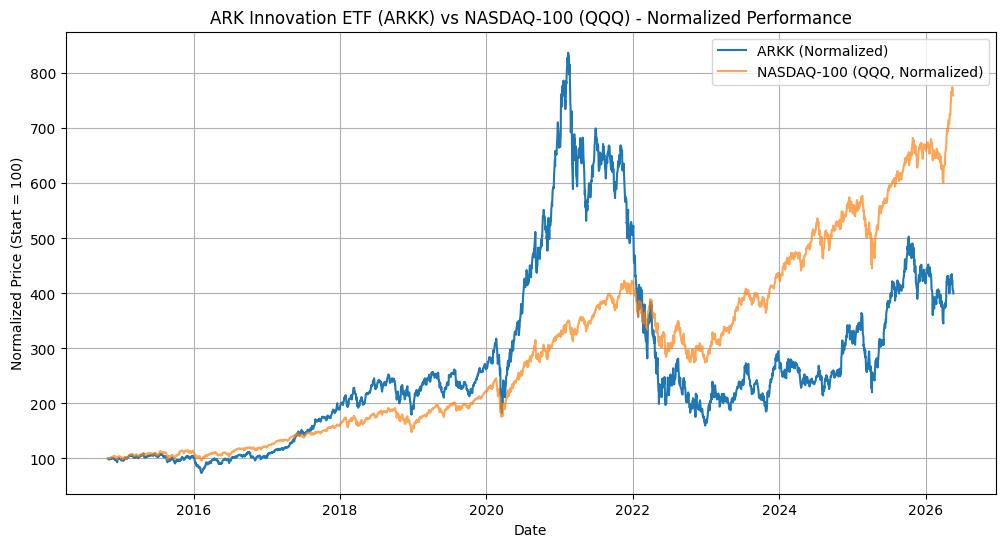

In [2]:
# Download historical data for ARKK and NASDAQ (QQQ as proxy)
ticker_arkk = yf.Ticker('ARKK')
df_arkk = ticker_arkk.history(period='max')

ticker_qqq = yf.Ticker('QQQ')  # QQQ ETF tracks the NASDAQ-100
# Align the period to ARKK's available data
df_qqq = ticker_qqq.history(start=df_arkk.index.min(), end=df_arkk.index.max())

# Normalize both to 100 at their respective start dates
df_arkk['Norm_Close'] = df_arkk['Close'] / df_arkk['Close'].iloc[0] * 100
df_qqq['Norm_Close'] = df_qqq['Close'] / df_qqq['Close'].iloc[0] * 100

# Plot the normalized closing prices
plt.figure(figsize=(12,6))
plt.plot(df_arkk.index, df_arkk['Norm_Close'], label='ARKK (Normalized)')
plt.plot(df_qqq.index, df_qqq['Norm_Close'], label='NASDAQ-100 (QQQ, Normalized)', alpha=0.7)
plt.title('ARK Innovation ETF (ARKK) vs NASDAQ-100 (QQQ) - Normalized Performance')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Start = 100)')
plt.legend()
plt.grid(True)
plt.show()

As you can see here, ARK Innovation ETF (and with 0.75%/year 2-3x as expensive as commcn NASDAQ ETFs, by the way) is not really performing well, many investors certainly even lost money buying in in 2021. But how big are it's deviation from it's real market value?

### Calculating the real market value of ARK Innovation ETF (ARKK)
Now let's start retrieving the historic holdings of this ETF. With this, we can then multiply the holdings (in percentage) with the stock market prices to get the real market value:

In [ ]:
# Retrieve and display the historic holdings of ARK Innovation ETF (ARKK) using the ark-invest-api
# Reference: https://github.com/frefrik/ark-invest-api

# URL for the ARK Invest API v2 endpoint for ETF holdings
url = "https://arkfunds.io/api/v2/etf/holdings"

# Parameters for the request to get all historical data
# Earliest available date for ARKK holdings is 2020-11-24
params = {
    'symbol': 'ARKK',
    'date_from': '2020-11-24',
    'date_to': datetime.today().strftime('%Y-%m-%d')
}

# Make the GET request to the API
response = requests.get(url, params=params)

# Check if the request was successful
if response.status_code == 200:
    # Parse the JSON response
    data = response.json()
    
    # Create a pandas DataFrame from the 'holdings' data
    if 'holdings' in data and data['holdings']:
        df_holdings = pd.DataFrame(data['holdings'])
        
        # Display the first few rows
        pd.set_option('display.max_columns', None)
        print(f"Successfully retrieved {len(df_holdings)} historical holding records for ARKK.")
        #display(df_holdings.head())
    else:
        print("No holdings data found for the given symbol and date range.")
else:
    print(f"Failed to retrieve data. Status code: {response.status_code}")
    print(response.text)

Successfully retrieved 53688 historical holding records for ARKK.


Now after retrieving that, we can check on how many dates the holdings are documented:

In [17]:
# Check the number of unique dates in the holdings data
if 'df_holdings' in locals():
    unique_dates = df_holdings['date'].nunique()
    print(f"There are {unique_dates} unique dates in the ARKK holdings data.")
else:
    print("Holdings data not found. Please run the previous cell to fetch the data.")

There are 1365 unique dates in the ARKK holdings data.


Now let's calculate the real market value: We multiply the closing price of each stock ARKK has as holdings and take into consideration that different position in the ETF make up a different proportion. After that, we should get the closing prices of ARKK for the dates that are defined.

In [22]:
# Calculate the real market value of ARKK based on its historical holdings

if 'df_holdings' in locals():
    print("Calculating real market value... This may take a moment.")
    
    # Get unique tickers and date range from holdings data
    # Drop any NaN/None tickers before getting the unique list
    unique_tickers = df_holdings['ticker'].dropna().unique().tolist()
    start_date = df_holdings['date'].min()
    end_date = df_holdings['date'].max()
    
    # Download historical price data for all tickers at once
    # Note: yfinance may have trouble with some tickers (e.g., delisted, changed).
    # We'll suppress errors for now and handle missing data later.
    with open(os.devnull, 'w') as devnull:
        old_stderr = sys.stderr
        sys.stderr = devnull
        try:
            all_prices = yf.download(unique_tickers, start=start_date, end=end_date, progress=False)
        finally:
            sys.stderr = old_stderr

    # We only need the 'Close' prices
    close_prices = all_prices['Close']
    
    # Dictionary to store the calculated real market value for each date
    real_market_values = {}
    
    # Group holdings by date and iterate
    for date, daily_holdings in df_holdings.groupby('date'):
        total_value = 0
        date_ts = pd.to_datetime(date) # Convert date string to timestamp
        
        for _, holding in daily_holdings.iterrows():
            ticker = holding['ticker']
            shares = holding['shares']
            
            # Check if we have price data for this ticker and date
            if ticker in close_prices.columns and date_ts in close_prices.index:
                price = close_prices.loc[date_ts, ticker]
                # If price is not NaN, calculate value
                if pd.notna(price):
                    total_value += shares * price
                    
        real_market_values[date_ts] = total_value
        
    # Create a new DataFrame with the calculated real market values
    df_real_market_value = pd.DataFrame(list(real_market_values.items()), columns=['Date', 'Real_Market_Value'])
    df_real_market_value = df_real_market_value.set_index('Date')
    
    print("Calculation complete.")
    #display(df_real_market_value.head())

else:
    print("Holdings data not found. Please run the cell that fetches 'df_holdings' first.")

Calculating real market value... This may take a moment.
Calculation complete.


In [25]:
df_real_market_value.shape

(1365, 1)

### Plot historic real market value of ARKK
Now, after calculating the real market value of ARKK, let's plot it:

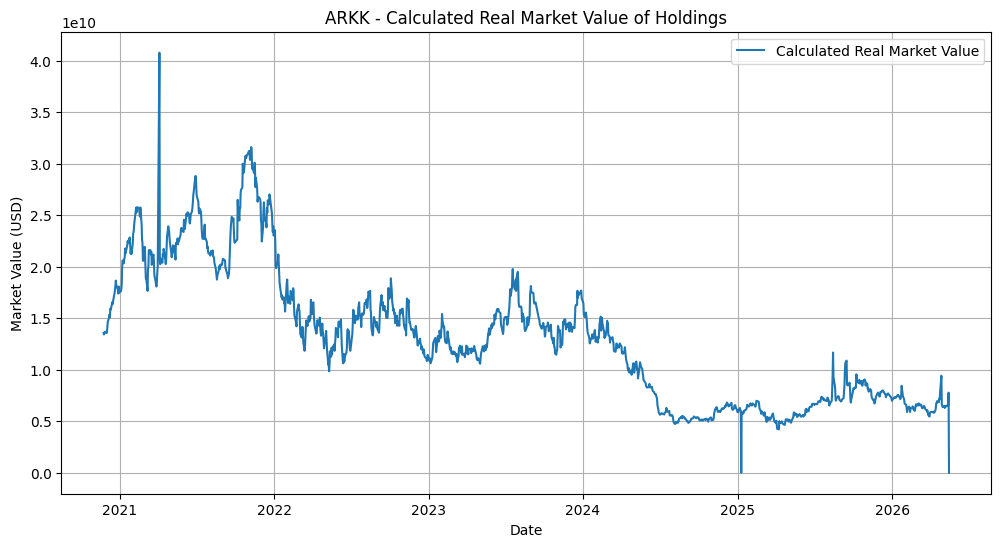

In [24]:
# Plot the calculated real market value over time

if 'df_real_market_value' in locals():
    plt.figure(figsize=(12,6))
    plt.plot(df_real_market_value.index, df_real_market_value['Real_Market_Value'], label='Calculated Real Market Value')
    plt.title('ARKK - Calculated Real Market Value of Holdings')
    plt.xlabel('Date')
    plt.ylabel('Market Value (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Real market value data not found. Please run the previous calculation cell first.")

Now let's compare the real market value with the displayed market value of ARKK. For that, we normalized both to make them comparable:

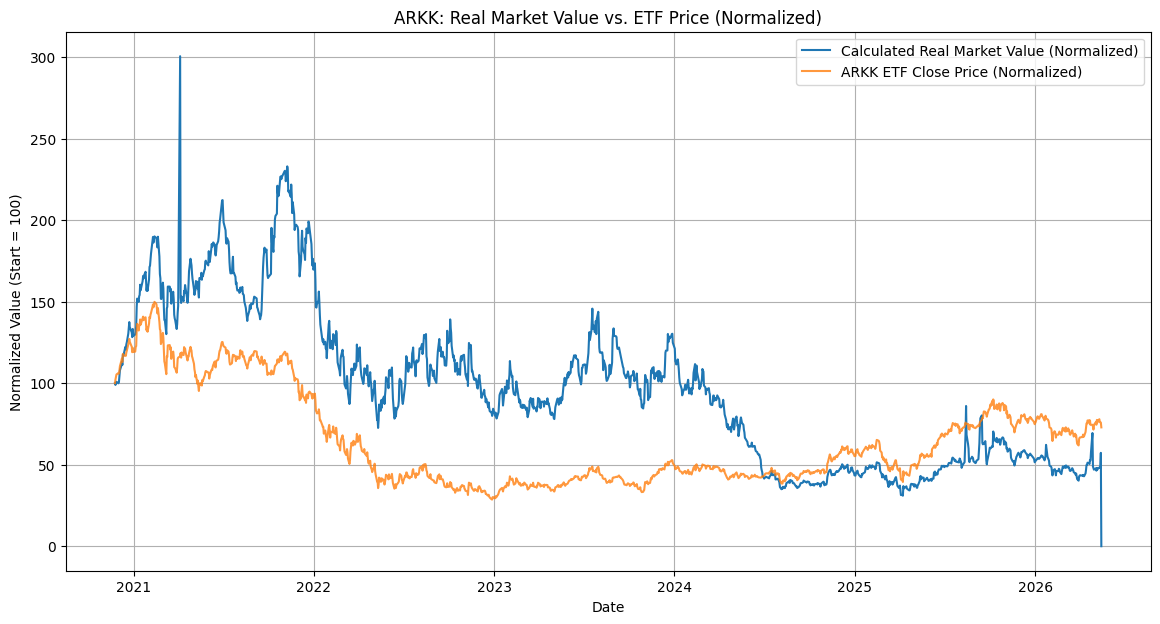

In [28]:
# Compare the ETF's closing price with its calculated real market value

if 'df_real_market_value' in locals() and 'df_arkk' in locals():
    # Make a copy to avoid SettingWithCopyWarning
    df_arkk_local = df_arkk.copy()
    
    # Remove timezone from the ARKK dataframe's index to allow merging
    df_arkk_local.index = df_arkk_local.index.tz_localize(None)
    
    # Merge the two dataframes on their date index
    # We use an inner join to only get dates where both values are available
    df_comparison = df_real_market_value.join(df_arkk_local['Close'], how='inner')
    
    if not df_comparison.empty:
        # Normalize both columns to 100 to compare growth
        df_comparison['Norm_Real_Value'] = df_comparison['Real_Market_Value'] / df_comparison['Real_Market_Value'].iloc[0] * 100
        df_comparison['Norm_Close'] = df_comparison['Close'] / df_comparison['Close'].iloc[0] * 100

        # Plot the normalized values
        plt.figure(figsize=(14, 7))
        plt.plot(df_comparison.index, df_comparison['Norm_Real_Value'], label='Calculated Real Market Value (Normalized)')
        plt.plot(df_comparison.index, df_comparison['Norm_Close'], label='ARKK ETF Close Price (Normalized)', alpha=0.8)
        
        plt.title('ARKK: Real Market Value vs. ETF Price (Normalized)')
        plt.xlabel('Date')
        plt.ylabel('Normalized Value (Start = 100)')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Could not find matching dates between real market value and ETF price data.")
else:
    print("Required data not found. Please run the previous cells to calculate real market value and download ARKK data.")

### Obervation
Interesting! As we can see, ARKK seemed to be massively underpriced (discount) from 2021 - mid 2024, but then overpriced (premium) from mid 2024 onwards. This seems to be really interesting, considering that we discussed in the beginning that the real market value and the displayed market value of an ETF should not deviate thats much. Let's see, how much it deviates:

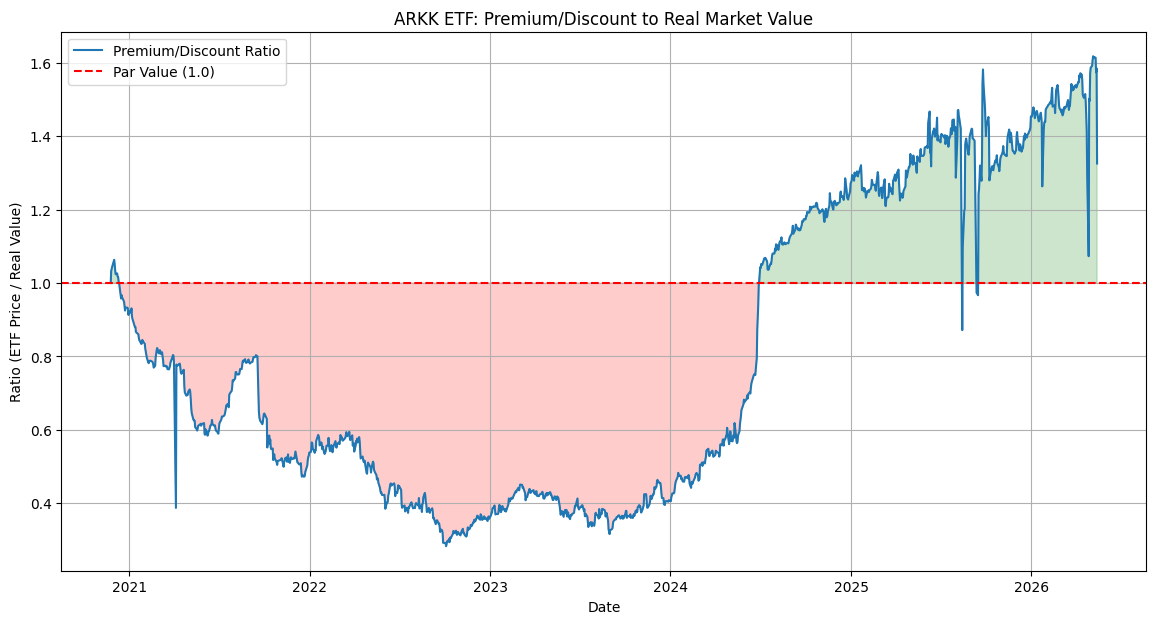

In [31]:
# Calculate and plot the premium/discount

if 'df_comparison' in locals() and not df_comparison.empty:
    # Calculate the premium/discount ratio
    # A value > 1 means premium (ETF price is higher than its parts)
    # A value < 1 means discount (ETF price is lower than its parts)
    df_comparison['Premium_Discount'] = df_comparison['Norm_Close'] / df_comparison['Norm_Real_Value']
    
    # Plot the premium/discount ratio
    plt.figure(figsize=(14, 7))
    plt.plot(df_comparison.index, df_comparison['Premium_Discount'], label='Premium/Discount Ratio')
    
    # Add a line at 1.0 for reference
    plt.axhline(y=1.0, color='r', linestyle='--', label='Par Value (1.0)')
    
    plt.title('ARKK ETF: Premium/Discount to Real Market Value')
    plt.xlabel('Date')
    plt.ylabel('Ratio (ETF Price / Real Value)')
    plt.legend()
    plt.grid(True)
    
    # Add text to clarify regions
    plt.fill_between(df_comparison.index, 1.0, df_comparison['Premium_Discount'], where=df_comparison['Premium_Discount'] >= 1.0, color='green', alpha=0.2, label='Premium')
    plt.fill_between(df_comparison.index, 1.0, df_comparison['Premium_Discount'], where=df_comparison['Premium_Discount'] <= 1.0, color='red', alpha=0.2, label='Discount')
    
    plt.show()
    
    # Display summary statistics for the ratio
    #print("Premium/Discount Ratio Statistics:")
    #display(df_comparison['Premium_Discount'].describe())
    
else:
    print("Comparison data not found. Please run the previous cells first.")

So here, we can see a *large* difference of real market value and displayed market value of ARKK. Very interesting to see! So in the next steps, let's discuss our findings and why it seems to be like that.

### Critique on methodology & data
So, after finding this extreme fact, let's discuss, where we had possible sources of errors that may have influenced our observation:
- incomplete/incorrect data: there is no garantee, that the historic performances listed on yahoo finance are all correct
- incomplete/incorrect holding percentages: we might not get every holding position in ARKK and there may also be some errors in the data. Furthermore, due to rounding inaccuracies, some positions may be smaller/bigger than in reality
- filtering dates: since only holdings of ARKK on some dates were available, we did not have the chance to compare other dates. Maybe the displayed market priced would update one day later after a real position change, so we would compare real market values from one date with the displayed market value of the day before
-  buying/selling cost: this model ignores the actual price that ARKK has payed for a certain stock or got for selling a position, which typically is higher than the displayed market value of a stock. Also, buying and seeling fees are not included in this model

### Further reasons
There are some other reasons on why there might be such a big deviation:
- reputation and market expectation: ARK Invest is a very controversial company, with many people believing it's vision of investing into disrupting technologies and others calling it a complete waste of money and hype. This media attention cetainly influences investing decisions into the ARKK ETF. With ARK Invest getting bigger over time, maybe media attention grew, leading to a premium now.
- activity: ARKK being an active ETF, instead of just copying an index, my make comparison for institutions and private investors harder, making deviations less visible
- size: ARKK is considered "medium"-size (https://de.finance.yahoo.com/quote/ARKK/profile/), so there may not be a lot of institutional investors checking on the real market value of ARKK and buying in at a discount and selling at premium

### Further methods and future plans
To make the methodology more stable and error-proof, our next step would be to track ARKK's historic trades, not only it's historic holding structure. Maybe this way, we can get rid of some sources of errors like buying/selling cost.

## Conclusion
So in general, we can say that ETFs typically reflect the value of the stocks contained in the ETF, but some of ETFs (primarily active ones) are less reliable in that. Their market value is also influenced by other factors such as reputation and media around the ETF. Generally, the bigger the ETF, the smaller it's deviation to real market value.